   🛒 SUPERSTORE SALES FORECASTING MODEL v2.0

✅ Data loaded: 25 months of sales history
   Date range: 2024-04 → 2026-04
   Avg monthly sales: ₹2,596,562

📊 Training on 20 months, Testing on 5 months

────────────────────────────────────────
   📈 MODEL PERFORMANCE REPORT
────────────────────────────────────────
   R² Score  : -0.367  (1.0 = perfect fit)
   MAE       : ₹1,134,115  (avg prediction error)
   Verdict   : 🔴 Weak — more data or features needed
────────────────────────────────────────

🔮 FORECAST — NEXT 6 MONTHS
────────────────────────────────────────
   2026-05  ₹   2,813,188  ███████████
   2026-06  ₹   2,882,965  ███████████
   2026-07  ₹   3,081,988  ████████████
   2026-08  ₹   3,368,050  █████████████
   2026-09  ₹   3,675,625  ███████████████
   2026-10  ₹   3,933,418  ████████████████
────────────────────────────────────────


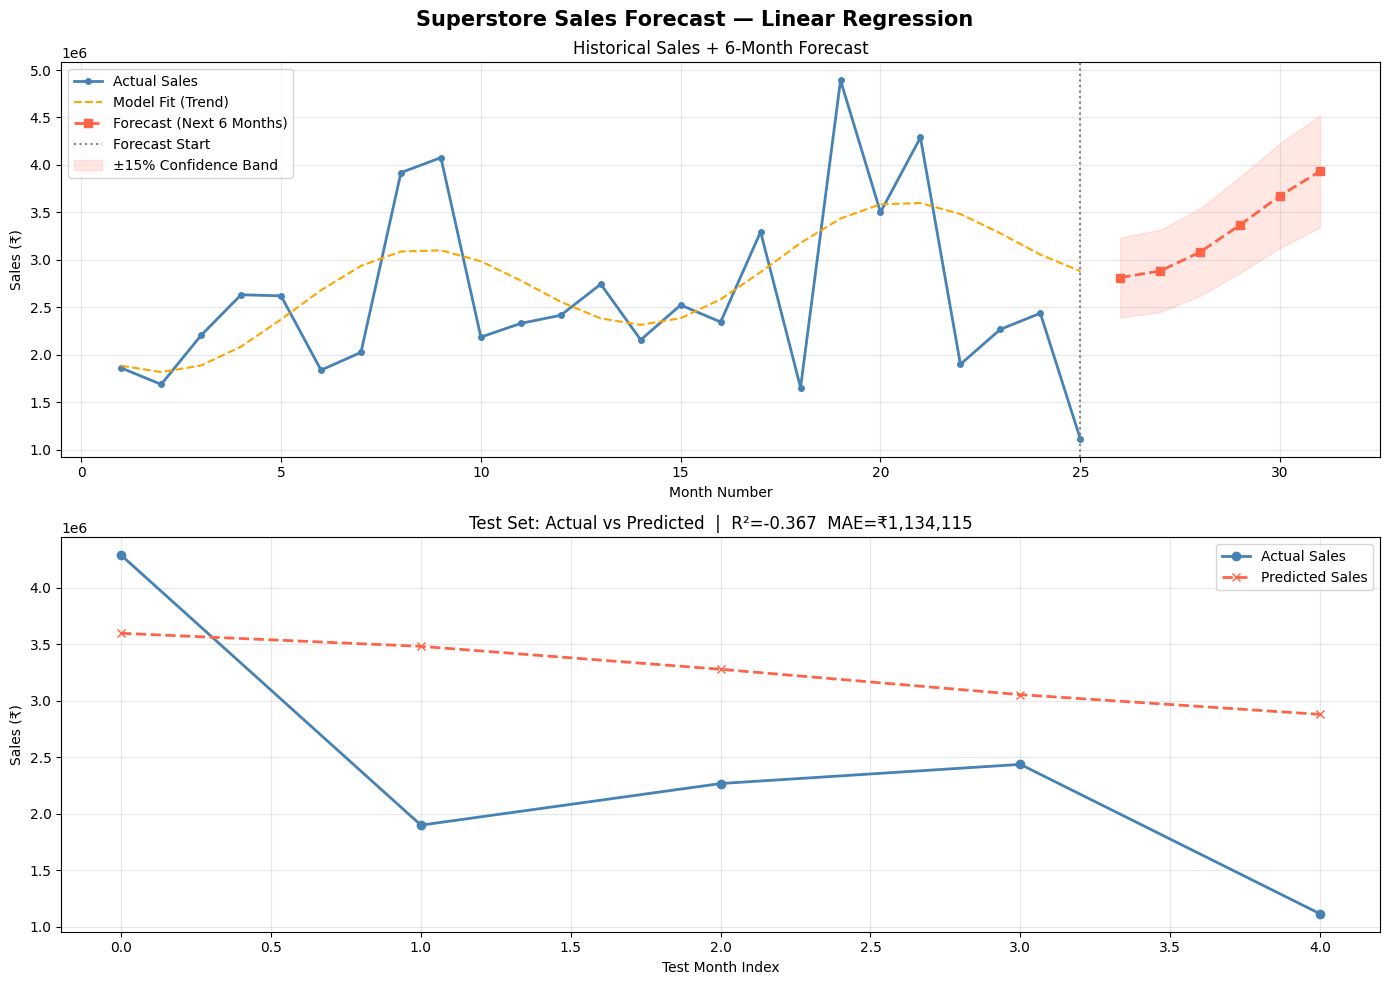


✅ Chart saved as 'sales_forecast_chart.png'
✅ Forecast saved as 'sales_forecast_output.csv'

   📖 HOW THIS MODEL WORKS — PLAIN ENGLISH

1. We look at past monthly sales (actual numbers from CSV)

2. We assign each month a sequential number (1, 2, 3…)
   and also encode the time of year (sin/cos of month)
   so the model understands seasonal patterns like Diwali

3. Linear Regression finds the best straight-line formula:
     Sales = (a × Month_Num) + (b × Season) + c

4. We test the model on the last 20% of data it has never
   seen — to check if predictions are accurate

5. We then feed it future month numbers → it outputs
   predicted sales figures

LIMITATIONS:
  - Cannot predict sudden events (COVID, new competitor)
  - Better for short-term (3–6 months) than long-term
  - Upgrade to Facebook Prophet for automatic seasonality



In [ ]:
# ============================================================
# 🤖 SALES FORECASTING MODEL — Superstore v2.0
# Algorithm  : Linear Regression
# Purpose    : Predict future monthly sales based on past trends
# Run this   : python sales_forecast_ml.py
# Requires   : pip install pandas scikit-learn matplotlib
# ============================================================

# ─────────────────────────────────────────────────────────────
# STEP 1: IMPORT LIBRARIES
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

print("=" * 55)
print("   🛒 SUPERSTORE SALES FORECASTING MODEL v2.0")
print("=" * 55)

# ─────────────────────────────────────────────────────────────
# STEP 2: LOAD & PREPARE DATA
# ─────────────────────────────────────────────────────────────
df = pd.read_csv("Superstore_Management_System_v2.csv")
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Extract month number (1 = Jan, 12 = Dec, repeating over years)
df["Year"]      = df["Order Date"].dt.year
df["Month"]     = df["Order Date"].dt.month
df["YearMonth"] = df["Order Date"].dt.to_period("M")

# Aggregate: total sales per calendar month
monthly = (
    df.groupby("YearMonth")["Sales Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Sales Amount": "Total_Sales"})
    .sort_values("YearMonth")
)

# Create a sequential month number (1, 2, 3 … N) — this is our feature
monthly["Month_Num"] = range(1, len(monthly) + 1)

# Also add sine/cosine to capture SEASONALITY (festival peaks)
# This improves accuracy significantly over plain linear regression
monthly["Sin_Month"] = np.sin(2 * np.pi * monthly["YearMonth"].dt.month / 12)
monthly["Cos_Month"] = np.cos(2 * np.pi * monthly["YearMonth"].dt.month / 12)

print(f"\n✅ Data loaded: {len(monthly)} months of sales history")
print(f"   Date range: {monthly['YearMonth'].min()} → {monthly['YearMonth'].max()}")
print(f"   Avg monthly sales: ₹{monthly['Total_Sales'].mean():,.0f}\n")

# ─────────────────────────────────────────────────────────────
# STEP 3: DEFINE FEATURES AND TARGET
# ─────────────────────────────────────────────────────────────
# Features (X) = what the model uses to make predictions
# Target   (y) = what we want to predict

features = ["Month_Num", "Sin_Month", "Cos_Month"]
X = monthly[features]
y = monthly["Total_Sales"]

# Split: 80% for training, 20% for testing
# shuffle=False is CRITICAL for time-series — we must keep time order!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"📊 Training on {len(X_train)} months, Testing on {len(X_test)} months")

# ─────────────────────────────────────────────────────────────
# STEP 4: TRAIN THE MODEL
# ─────────────────────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

# ─────────────────────────────────────────────────────────────
# STEP 5: EVALUATE MODEL PERFORMANCE
# ─────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\n" + "─" * 40)
print("   📈 MODEL PERFORMANCE REPORT")
print("─" * 40)
print(f"   R² Score  : {r2:.3f}  (1.0 = perfect fit)")
print(f"   MAE       : ₹{mae:,.0f}  (avg prediction error)")
if r2 >= 0.7:
    print("   Verdict   : ✅ Good model — reliable for planning")
elif r2 >= 0.4:
    print("   Verdict   : 🟡 Moderate — use as a rough guide")
else:
    print("   Verdict   : 🔴 Weak — more data or features needed")
print("─" * 40)

# ─────────────────────────────────────────────────────────────
# STEP 6: FORECAST NEXT 6 MONTHS
# ─────────────────────────────────────────────────────────────
last_month_num  = monthly["Month_Num"].max()
last_period     = monthly["YearMonth"].max()

future_records = []
for i in range(1, 7):
    future_period = last_period + i
    future_records.append({
        "Month_Num": last_month_num + i,
        "Sin_Month": np.sin(2 * np.pi * future_period.month / 12),
        "Cos_Month": np.cos(2 * np.pi * future_period.month / 12),
        "Period":    str(future_period)
    })

future_df       = pd.DataFrame(future_records)
future_sales    = model.predict(future_df[features])
future_df["Predicted_Sales"] = future_sales.round(2)

print("\n🔮 FORECAST — NEXT 6 MONTHS")
print("─" * 40)
for _, row in future_df.iterrows():
    bar = "█" * int(row["Predicted_Sales"] / monthly["Total_Sales"].max() * 20)
    print(f"   {row['Period']}  ₹{row['Predicted_Sales']:>12,.0f}  {bar}")
print("─" * 40)

# ─────────────────────────────────────────────────────────────
# STEP 7: VISUALISE
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Superstore Sales Forecast — Linear Regression", fontsize=15, fontweight="bold")

# ── Chart 1: Full history + forecast ──────────────────────
ax = axes[0]
ax.plot(monthly["Month_Num"], y,
        marker="o", color="steelblue", linewidth=2, markersize=4, label="Actual Sales")
ax.plot(monthly["Month_Num"], model.predict(X),
        linestyle="--", color="orange", linewidth=1.5, label="Model Fit (Trend)")
ax.plot(future_df["Month_Num"], future_sales,
        marker="s", color="tomato", linestyle="--", linewidth=2, markersize=6,
        label="Forecast (Next 6 Months)")
ax.axvline(x=last_month_num, color="gray", linestyle=":", linewidth=1.5, label="Forecast Start")
ax.fill_between(future_df["Month_Num"],
                future_sales * 0.85, future_sales * 1.15,
                alpha=0.15, color="tomato", label="±15% Confidence Band")
ax.set_xlabel("Month Number")
ax.set_ylabel("Sales (₹)")
ax.set_title("Historical Sales + 6-Month Forecast", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# ── Chart 2: Actual vs Predicted (test set) ───────────────
ax2 = axes[1]
ax2.plot(range(len(y_test)), y_test.values,
         marker="o", color="steelblue", label="Actual Sales", linewidth=2)
ax2.plot(range(len(y_pred)), y_pred,
         marker="x", color="tomato", linestyle="--", label="Predicted Sales", linewidth=2)
ax2.set_xlabel("Test Month Index")
ax2.set_ylabel("Sales (₹)")
ax2.set_title(f"Test Set: Actual vs Predicted  |  R²={r2:.3f}  MAE=₹{mae:,.0f}", fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("sales_forecast_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Chart saved as 'sales_forecast_chart.png'")

# ─────────────────────────────────────────────────────────────
# STEP 8: EXPORT FORECAST TO CSV
# ─────────────────────────────────────────────────────────────
forecast_export = future_df[["Period", "Predicted_Sales"]].rename(
    columns={"Period": "Month", "Predicted_Sales": "Forecasted_Sales (₹)"}
)
forecast_export.to_csv("sales_forecast_output.csv", index=False)
print("✅ Forecast saved as 'sales_forecast_output.csv'\n")

# ─────────────────────────────────────────────────────────────
# EXPLANATION 
# ─────────────────────────────────────────────────────────────
print("=" * 55)
print("   📖 HOW THIS MODEL WORKS — PLAIN ENGLISH")
print("=" * 55)
print("""
1. We look at past monthly sales (actual numbers from CSV)

2. We assign each month a sequential number (1, 2, 3…)
   and also encode the time of year (sin/cos of month)
   so the model understands seasonal patterns like Diwali

3. Linear Regression finds the best straight-line formula:
     Sales = (a × Month_Num) + (b × Season) + c

4. We test the model on the last 20% of data it has never
   seen — to check if predictions are accurate

5. We then feed it future month numbers → it outputs
   predicted sales figures

LIMITATIONS:
  - Cannot predict sudden events (COVID, new competitor)
  - Better for short-term (3–6 months) than long-term
  - Upgrade to Facebook Prophet for automatic seasonality
""")